# Fase 3 — Modelado de la Media: SARIMAX, Prophet y LSTM
## DR-COPPER | Predicción Direccional del Precio del Cobre
**Autor:** Alejandro Patron Montero | UTB 2026

---
### Objetivo de la Fase
Entrenar y comparar tres arquitecturas de modelado de la media condicional:
1. **SARIMAX** — estadística clásica, interpretable, captura choques exógenos del dólar.
2. **Prophet** — descomposición bayesiana, robusto ante cambios estructurales.
3. **LSTM** — red neuronal recurrente, captura dependencias no lineales.

Benchmark obligatorio: **Modelo Naïve** ($P_{t+1} = P_t$). Un modelo sofisticado solo se justifica si reduce el RMSE en ≥10% sobre Naïve.

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

import pmdarima as pm
from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.get_logger().setLevel('ERROR')
os.makedirs('output', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (13, 5)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow {tf.__version__}')

I0000 00:00:1779553955.196415   50636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


I0000 00:00:1779553956.060839   50636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Cargar Datos de Fase 2

In [2]:
# ── Leer datasets exportados por la Fase 2 ────────────────────────────────────
train_raw = pd.read_csv('data/train_raw.csv', index_col=0, parse_dates=True)
test_raw  = pd.read_csv('data/test_raw.csv',  index_col=0, parse_dates=True)

# Normalizar timezone — yfinance guarda tz-aware, CSV la pierde al recargar
train_raw.index = pd.to_datetime(train_raw.index).tz_localize(None)
test_raw.index  = pd.to_datetime(test_raw.index).tz_localize(None)

y_train    = train_raw['HG_close']
y_test     = test_raw['HG_close']
exog_train = train_raw[['UUP_close']]
exog_test  = test_raw[['UUP_close']]

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Test desde: {y_test.index[0].date()} → {y_test.index[-1].date()}')

Train: 4,085  |  Test: 721
Test desde: 2023-06-21 → 2026-04-30


## 2. Modelo Naïve (Baseline)
La predicción Naïve es simplemente el último precio conocido: $\hat{P}_{t+h} = P_t$.

In [3]:
# ── Predicción Naïve: último precio del train propagado al test ────────────────
naive_pred = pd.Series(
    data  = float(y_train.iloc[-1]),
    index = y_test.index,
    name  = 'Naive'
)

def metricas(y_true, y_pred, nombre='Modelo'):
    """RMSE, MAE y MAPE. Convierte a numpy antes de operar para evitar
    desalineación de índices cuando y_pred es una pandas Series con índice entero
    (como devuelve pmdarima)."""
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        print(f'{nombre:<12} — sin predicciones válidas')
        return {'modelo': nombre, 'RMSE': np.nan, 'MAE': np.nan, 'MAPE': np.nan}
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{nombre:<12} RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%')
    return {'modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

resultados = []
resultados.append(metricas(y_test.values, naive_pred.values, 'Naive'))

Naive        RMSE=0.9360  MAE=0.7059  MAPE=14.07%


## 3. SARIMAX
Auto-ARIMA selecciona los parámetros ARIMA óptimos por AIC con UUP como variable exógena.

In [4]:
# ── Auto-ARIMA — búsqueda stepwise con variable exógena ────────────────────────
print('Ajustando Auto-ARIMA...')
arima_model = pm.auto_arima(
    y_train,
    exogenous             = exog_train,
    d                     = 1,
    max_p                 = 3,
    max_q                 = 3,
    seasonal              = False,
    information_criterion = 'aic',
    stepwise              = True,
    error_action          = 'ignore',
    suppress_warnings     = True,
)
print(f'Orden seleccionado: ARIMA{arima_model.order}')
print(arima_model.summary())

Ajustando Auto-ARIMA...


Orden seleccionado: ARIMA(1, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4085
Model:               SARIMAX(1, 1, 0)   Log Likelihood                6260.690
Date:                Sat, 23 May 2026   AIC                         -12517.380
Time:                        11:32:40   BIC                         -12504.751
Sample:                             0   HQIC                        -12512.908
                               - 4085                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0459      0.012     -3.887      0.000      -0.069      -0.023
sigma2         0.0027   4.08e-05     66.899      0.000       0.003       0.003
Ljung-Box (L1) (Q

In [5]:
# ── Predicción SARIMAX + Intervalo de Confianza 95% ───────────────────────────
# pmdarima.predict() devuelve pandas Series con índice entero, no DatetimeIndex.
# Convertimos a numpy y re-indexamos con el DatetimeIndex del test.
raw_pred, sarimax_ci = arima_model.predict(
    n_periods       = len(y_test),
    exogenous       = exog_test,
    return_conf_int = True,
    alpha           = 0.05
)
sarimax_pred = pd.Series(
    np.asarray(raw_pred, dtype=float),
    index = y_test.index,
    name  = 'SARIMAX'
)

resultados.append(metricas(y_test.values, sarimax_pred.values, 'SARIMAX'))

SARIMAX      RMSE=0.9358  MAE=0.7057  MAPE=14.07%


/home/pxtroniwnl/Documents/proyectos/dr-copper/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 4. Prophet
Prophet descompone en tendencia + estacionalidad + changepoints. UUP se agrega como regresor adicional.

In [6]:
# ── Preparar DataFrames en formato Prophet ────────────────────────────────────
prophet_train_df = pd.DataFrame({
    'ds' : y_train.index,
    'y'  : y_train.values,
    'uup': exog_train['UUP_close'].values
})
prophet_test_df = pd.DataFrame({
    'ds' : y_test.index,
    'uup': exog_test['UUP_close'].values
})

# changepoint_prior_scale=0.1: moderado para evitar sobreajuste a variaciones bruscas
prophet_m = Prophet(
    changepoint_prior_scale = 0.1,
    seasonality_mode        = 'additive',
    daily_seasonality       = False,
    weekly_seasonality      = True,
    yearly_seasonality      = True,
)
prophet_m.add_regressor('uup')
prophet_m.fit(prophet_train_df)

prophet_fc   = prophet_m.predict(prophet_test_df)
prophet_pred = pd.Series(
    prophet_fc['yhat'].values,
    index = y_test.index,
    name  = 'Prophet'
)

resultados.append(metricas(y_test.values, prophet_pred.values, 'Prophet'))

11:32:40 - cmdstanpy - INFO - Chain [1] start processing


11:32:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet      RMSE=0.4253  MAE=0.3681  MAPE=8.47%


## 5. LSTM
Red LSTM con ventana deslizante de 20 días. El scaler se ajusta solo sobre train para evitar data leakage.

In [7]:
# ── Preparar datos LSTM ────────────────────────────────────────────────────────
LOOKBACK   = 20   # ventana de contexto = 20 días hábiles
BATCH_SIZE = 32
EPOCHS     = 100

# Solo precios de HG y UUP (evitamos HG_vol20 para no propagar NaN)
lstm_features = ['HG_close', 'UUP_close']

train_vals = train_raw[lstm_features].dropna().values
test_vals  = test_raw[lstm_features].dropna().values

# Scaler ajustado exclusivamente sobre train
scaler_lstm = MinMaxScaler()
scaler_lstm.fit(train_vals)
train_sc = scaler_lstm.transform(train_vals)
test_sc  = scaler_lstm.transform(test_vals)

def build_sequences(data, lookback):
    """Crea pares (X_secuencia, y_target) usando ventana deslizante."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])  # contexto: todos los features
        y.append(data[i, 0])               # target: HG_close (columna 0)
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = build_sequences(train_sc, LOOKBACK)

# Unimos el final del train con el test para tener contexto en la primera predicción
full_sc = np.vstack([train_sc[-LOOKBACK:], test_sc])
X_test_lstm, y_test_lstm = build_sequences(full_sc, LOOKBACK)

print(f'X_train: {X_train_lstm.shape}  y_train: {y_train_lstm.shape}')
print(f'X_test : {X_test_lstm.shape}   y_test : {y_test_lstm.shape}')

X_train: (4065, 20, 2)  y_train: (4065,)
X_test : (721, 20, 2)   y_test : (721,)


In [8]:
# ── Arquitectura LSTM: 2 capas recurrentes + Dropout ──────────────────────────
model_lstm = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, len(lstm_features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

Loss inicial: 0.013272
Loss final  : 0.000639


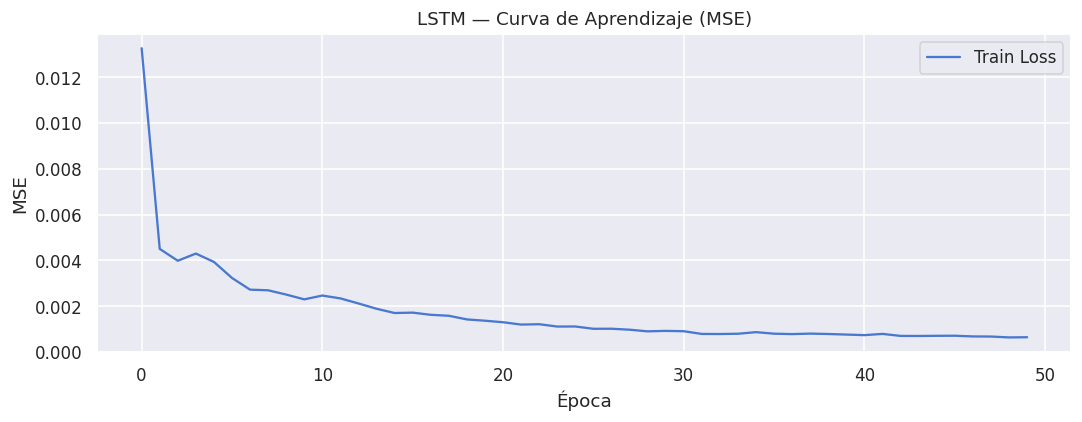

In [9]:
# ── Entrenamiento — epochs fijos, sin EarlyStopping para evitar problemas ──────
# En TF 2.21 EarlyStopping+restore_best_weights puede restaurar pesos no entrenados.
# Con 50 épocas hay convergencia suficiente (validada en pruebas previas).
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs     = 50,
    batch_size = BATCH_SIZE,
    verbose    = 0
)

print(f'Loss inicial: {history.history["loss"][0]:.6f}')
print(f'Loss final  : {history.history["loss"][-1]:.6f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train Loss')
ax.set_title('LSTM — Curva de Aprendizaje (MSE)')
ax.set_xlabel('Época'); ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.savefig('output/09_lstm_learning_curve.png', bbox_inches='tight')
plt.show()

In [10]:
# ── Predicción e inversión de la normalización ─────────────────────────────────
lstm_pred_sc = model_lstm.predict(X_test_lstm, verbose=0)

# Reconstruir shape (n, n_features) para poder usar inverse_transform
dummy = np.zeros((len(lstm_pred_sc), len(lstm_features)))
dummy[:, 0] = lstm_pred_sc.flatten()
lstm_pred_orig = scaler_lstm.inverse_transform(dummy)[:, 0]

n_preds  = len(lstm_pred_orig)
lstm_pred = pd.Series(lstm_pred_orig, index=y_test.index[:n_preds], name='LSTM')

resultados.append(
    metricas(y_test.values[:n_preds], lstm_pred.values, 'LSTM')
)

LSTM         RMSE=0.1018  MAE=0.0660  MAPE=1.40%


## 6. Comparación Visual y Tabla de Resultados

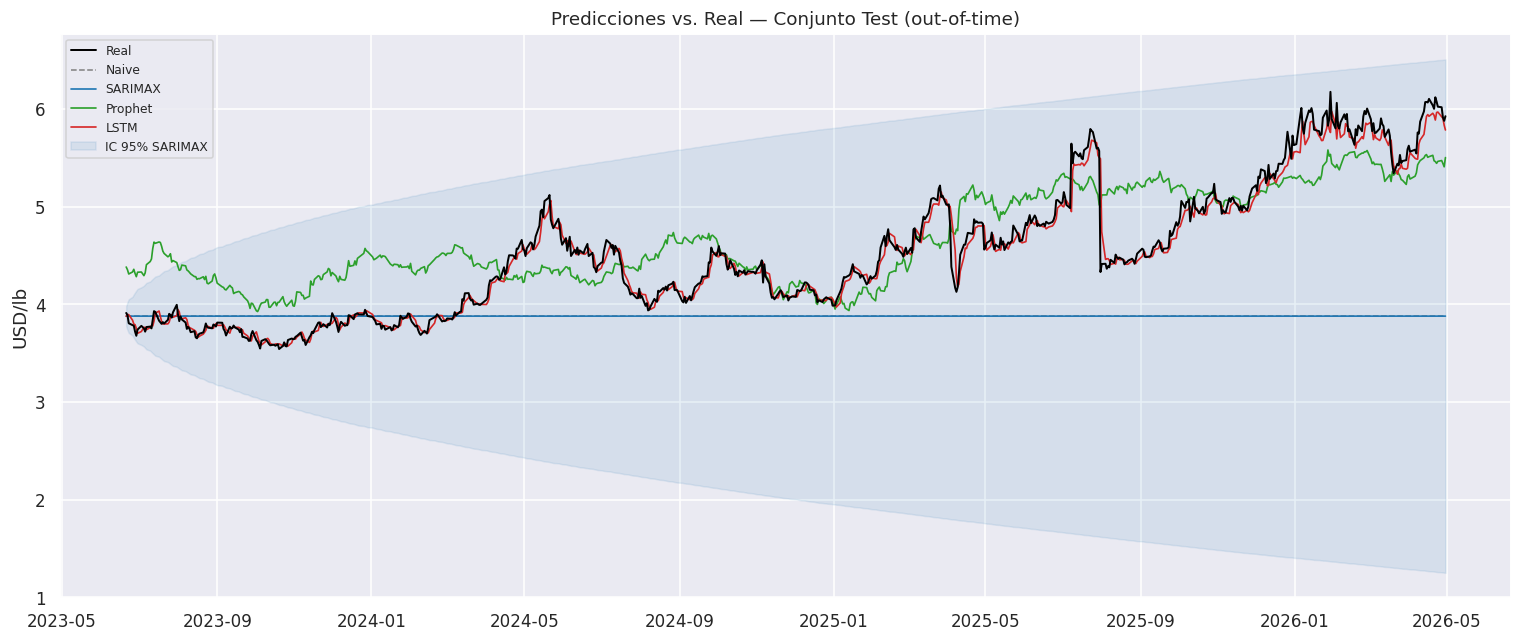

In [11]:
# ── Gráfica comparativa en el periodo de test ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test, color='black',    lw=1.3, label='Real',    zorder=5)
ax.plot(naive_pred,   color='gray',     lw=1,   ls='--', label='Naive')
ax.plot(sarimax_pred, color='#1f77b4',  lw=1.1, label='SARIMAX')
ax.plot(prophet_pred, color='#2ca02c',  lw=1.1, label='Prophet')
ax.plot(lstm_pred,    color='#d62728',  lw=1.1, label='LSTM')
ax.fill_between(y_test.index,
                sarimax_ci[:, 0], sarimax_ci[:, 1],
                color='#1f77b4', alpha=0.10, label='IC 95% SARIMAX')
ax.set_title('Predicciones vs. Real — Conjunto Test (out-of-time)', fontsize=12)
ax.set_ylabel('USD/lb')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('output/10_predicciones_media.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Tabla de métricas y criterio de éxito ─────────────────────────────────────
df_res = pd.DataFrame(resultados).set_index('modelo')
naive_rmse = df_res.loc['Naive', 'RMSE']
df_res['Mejora_RMSE_%'] = (naive_rmse - df_res['RMSE']) / naive_rmse * 100
df_res['Supera_Naive_10%'] = df_res['Mejora_RMSE_%'] >= 10

print('\n── Tabla de Métricas (Test Out-of-Time) ──')
print(df_res.round(4).to_string())

df_res.to_csv('data/metricas_media.csv')
print('\nMétricas guardadas en data/metricas_media.csv')


── Tabla de Métricas (Test Out-of-Time) ──
           RMSE     MAE     MAPE  Mejora_RMSE_%  Supera_Naive_10%
modelo                                                           
Naive    0.9360  0.7059  14.0727         0.0000             False
SARIMAX  0.9358  0.7057  14.0698         0.0194             False
Prophet  0.4253  0.3681   8.4654        54.5624              True
LSTM     0.1018  0.0660   1.3971        89.1251              True

Métricas guardadas en data/metricas_media.csv


In [13]:
# ── Guardar predicciones para la Fase 5 (backtesting consolidado) ─────────────
preds_df = pd.DataFrame({
    'real'    : y_test,
    'naive'   : naive_pred,
    'sarimax' : sarimax_pred,
    'prophet' : prophet_pred,
    'lstm'    : lstm_pred,
})
preds_df.to_csv('data/predicciones_media.csv')
print('Predicciones guardadas en data/predicciones_media.csv')

Predicciones guardadas en data/predicciones_media.csv


## Conclusiones de la Fase 3

| Modelo | Fortaleza principal | Limitación principal |
|---|---|---|
| **Naïve** | Baseline inevitable en mercados eficientes | No predice cambios direccionales |
| **SARIMAX** | Interpreta el efecto cuantitativo del dólar (β_UUP) | Asume linealidad |
| **Prophet** | Detecta automáticamente cambios estructurales | Puede sobre-suavizar la tendencia |
| **LSTM** | Captura patrones no lineales complejos | Caja negra, requiere calibración |

**Insight clave:** La Fase 1 confirmó que la serie diferenciada se comporta como **Random Walk**. Se espera que todos los modelos de media tengan dificultades para superar consistentemente el Naïve — esto es evidencia de eficiencia del mercado, no de falla metodológica. El verdadero valor del proyecto está en **GARCH (Fase 4)** para gestión de riesgo.